# Setup

In [50]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# import pandas_datareader.data as web
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modeling
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
from statsmodels.tsa.stattools import acf, pacf
# import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model


pd.set_option("display.max_columns",80)

In [2]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-03-21


# Data

In [3]:
%%time
start_date = "2018-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE', "AAPL", "META", "TSLA", "^GSPC","MSFT",]
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
all_data.info()

The number of stock to download are 10
[*********************100%***********************]  10 of 10 completed
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1312 entries, 2018-01-02 00:00:00-05:00 to 2023-03-20 00:00:00-04:00
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   1312 non-null   float64
 1   (Adj Close, DIS)    1312 non-null   float64
 2   (Adj Close, KO)     1312 non-null   float64
 3   (Adj Close, MAT)    1312 non-null   float64
 4   (Adj Close, META)   1312 non-null   float64
 5   (Adj Close, MSFT)   1312 non-null   float64
 6   (Adj Close, NVDA)   1312 non-null   float64
 7   (Adj Close, PFE)    1312 non-null   float64
 8   (Adj Close, TSLA)   1312 non-null   float64
 9   (Adj Close, ^GSPC)  1312 non-null   float64
 10  (Close, AAPL)       1312 non-null   float64
 11  (Close, DIS)        1312 non-null   float64
 12  (Close, KO)         1312 non-null   float64


In [4]:
adj_close_data_completed = all_data["Adj Close"].copy()
adj_close_data_completed.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.888058,108.726059,38.548210,16.020000,181.419998,80.738182,49.326286,28.559780,21.368668,2695.810059
2018-01-03 00:00:00-05:00,40.880947,109.192848,38.463554,16.139999,184.669998,81.113914,52.572647,28.771391,21.150000,2713.060059
2018-01-04 00:00:00-05:00,41.070835,109.144241,39.005302,15.910000,184.330002,81.827812,52.849777,28.834093,20.974667,2723.989990
2018-01-05 00:00:00-05:00,41.538441,108.551003,38.996834,16.260000,186.850006,82.842354,53.297630,28.888956,21.105333,2743.149902
2018-01-08 00:00:00-05:00,41.384159,106.994995,38.937576,15.810000,188.279999,82.926865,54.930717,28.567616,22.427334,2747.709961


# What is a time series?

A time series is a series of data points indexed (or listed or graphed) in time order most commonly, a time series is a sequence taken at successive equally spaced points in time. Thus it is a sequence of discrete-time data.


## Components of a Time-Series

* Trend - The trend shows a general direction of the time series data over a long period of time. A trend can be increasing(upward), decreasing(downward), or horizontal(stationary).
* Seasonality - The seasonality component exhibits a trend that repeats with respect to timing, direction, and magnitude. Some examples include an increase in water consumption in summer due to hot weather conditions.
* Cyclical Component - These are the trends with no set repetition over a particular period of time. A cycle refers to the period of ups and downs, booms and slums of a time series, mostly observed in business cycles. These cycles do not exhibit a seasonal variation but generally occur over a time period of 3 to 12 years depending on the nature of the time series.
* Irregular Variation - These are the fluctuations in the time series data which become evident when trend and cyclical variations are removed. These variations are unpredictable, erratic, and may or may not be random.
* ETS Decomposition - ETS Decomposition is used to separate different components of a time series. The term ETS stands for Error, Trend and Seasonality.

## Stationarity

<!-- <img src="../../img/.png" alt="MarineGEO circle logo" style="height: 350px; width:850px;"/> -->
<img src="../../img/time_series/image-asset.png" alt="stationarity" style="height: 850px; width:650px;"/>


## Autocorrelation

Essentially when we model a time series we decompose the series into three components: trend, seasonal/cyclical, and random. The random component is called the residual or error. It is simply the difference between our predicted value(s) and the observed value(s). Serial correlation is when the residuals (errors) of our TS models are correlated with each other.

## Why Do We Care about Serial Correlation? 

We care about serial correlation because it is critical for the validity of our model predictions, and is intrinsically related to stationarity. Recall that the residuals (errors) of a stationary TS are serially uncorrelated by definition! If we fail to account for this in our models the standard errors of our coefficients are underestimated, inflating the size of our T-statistics. The result is too many Type-1 errors, where we reject our null hypothesis even when it is True! In layman's terms, ignoring autocorrelation means our model predictions will be bunk, and we're likely to draw incorrect conclusions about the impact of the independent variables in our model. 

In [5]:
apple_data = adj_close_data_completed['AAPL'].copy().reset_index().rename(
    columns={
        "AAPL":"value",
        "Date":"date"
    }
)
apple_data['date'] = pd.to_datetime(apple_data['date'].dt.date)

apple_data = apple_data[
    apple_data.date >= "2021-01-01"
].reset_index(
    drop =True
)

apple_data['log_returns'] = np.log(apple_data.value.pct_change() + 1)

    
apple_data.head()

,date,value,log_returns
0,2021-01-04,127.680008,NaN
1,2021-01-05,129.258606,0.012288
2,2021-01-06,124.907578,-0.034241
3,2021-01-07,129.169800,0.033554
4,2021-01-08,130.284698,0.008594


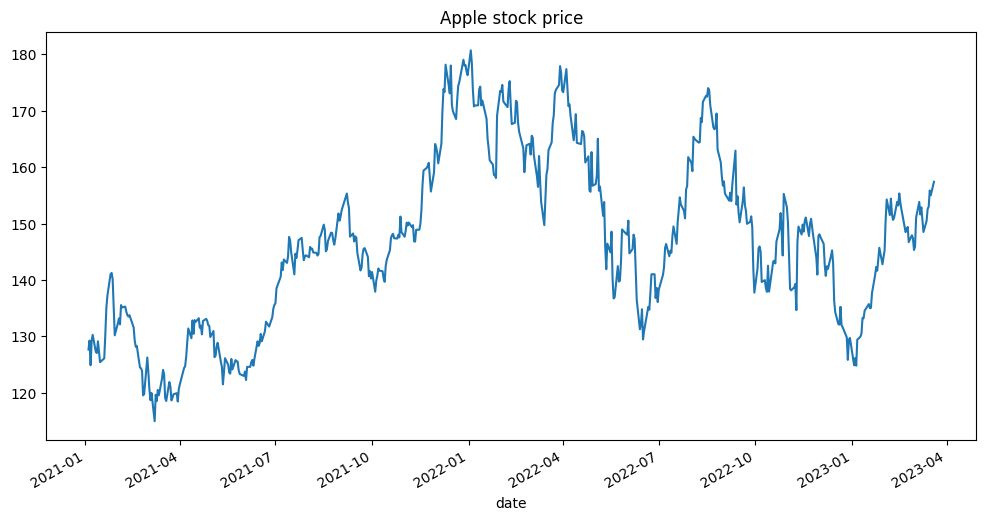

In [6]:
apple_data.set_index('date').value.plot(
    figsize=(12,6)
);
plt.title("Apple stock price");

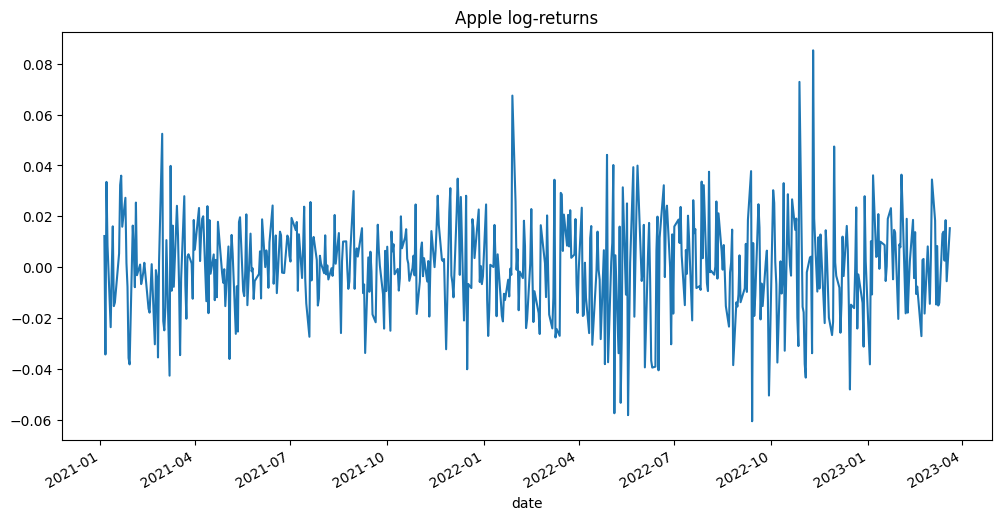

In [7]:
apple_data.set_index('date').log_returns.dropna().plot(
    figsize=(12,6)
);
plt.title("Apple log-returns");

In [8]:
apple_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         556 non-null    datetime64[ns]
 1   value        556 non-null    float64       
 2   log_returns  555 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 13.2 KB


In [9]:
apple_data.date.dt.to_period('Y').value_counts()

2021    252
2022    251
2023     53
Freq: A-DEC, Name: date, dtype: int64

# Decomposition of a Time Series 

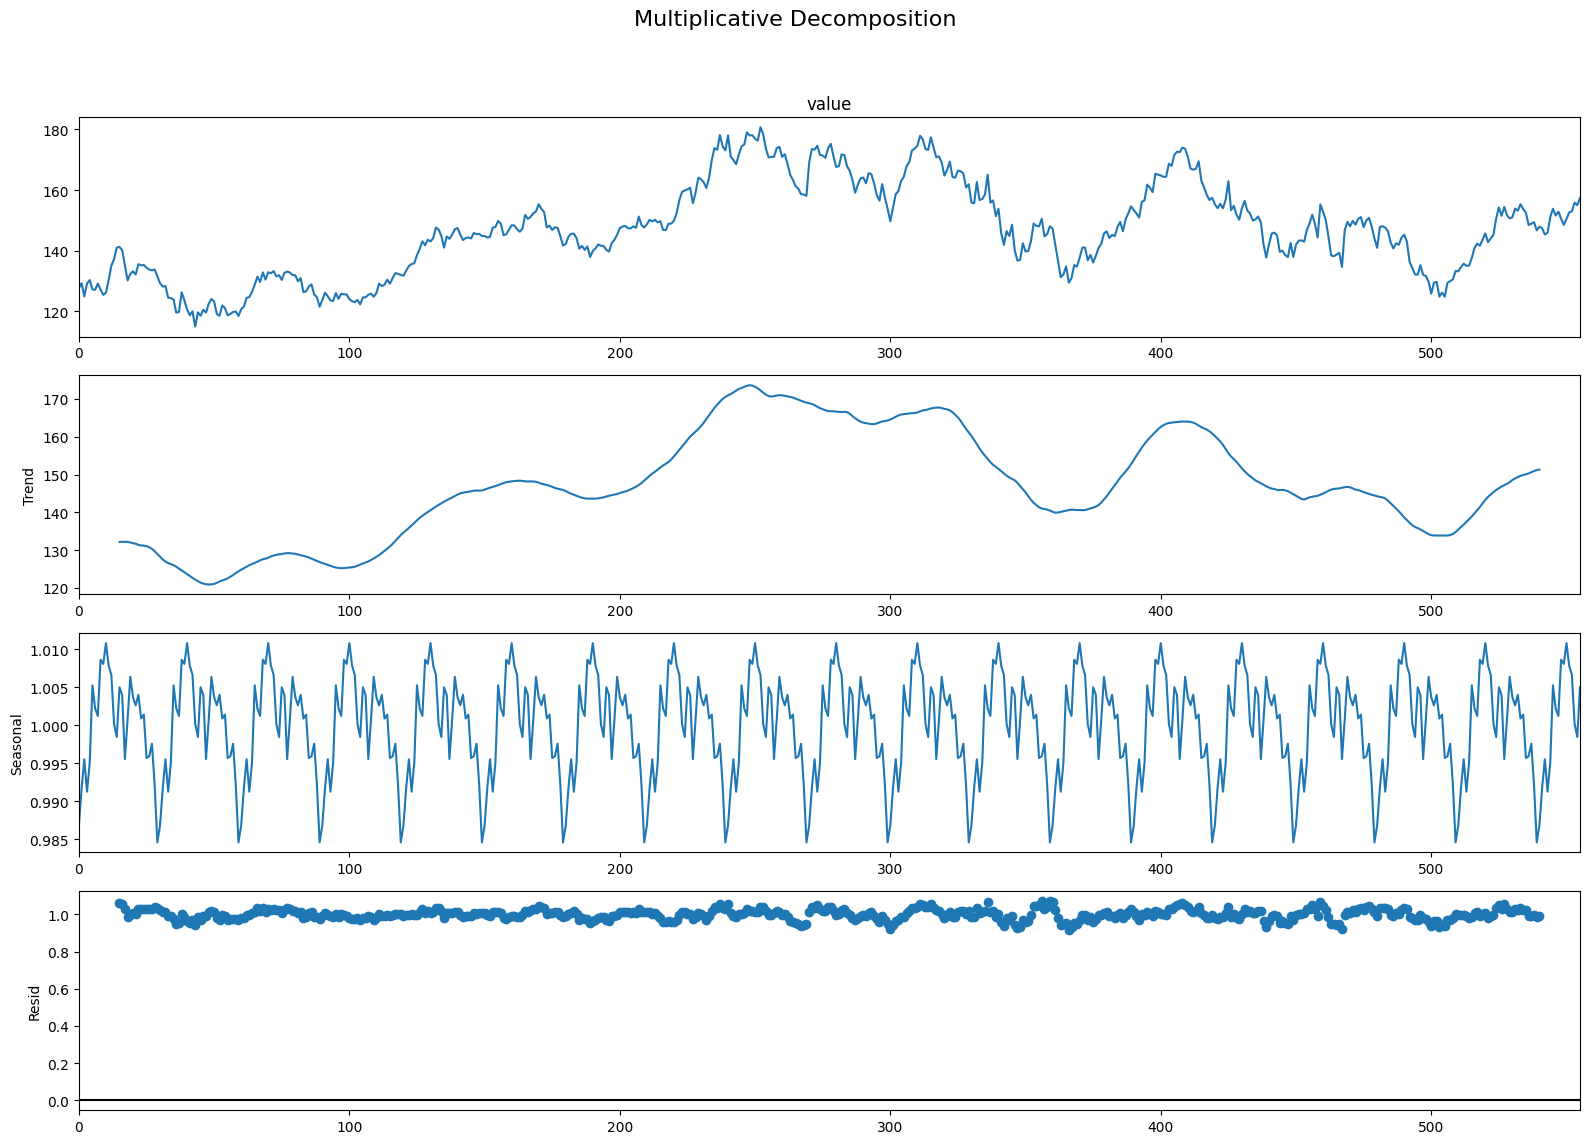

In [42]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(apple_data['value'], model='multiplicative', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

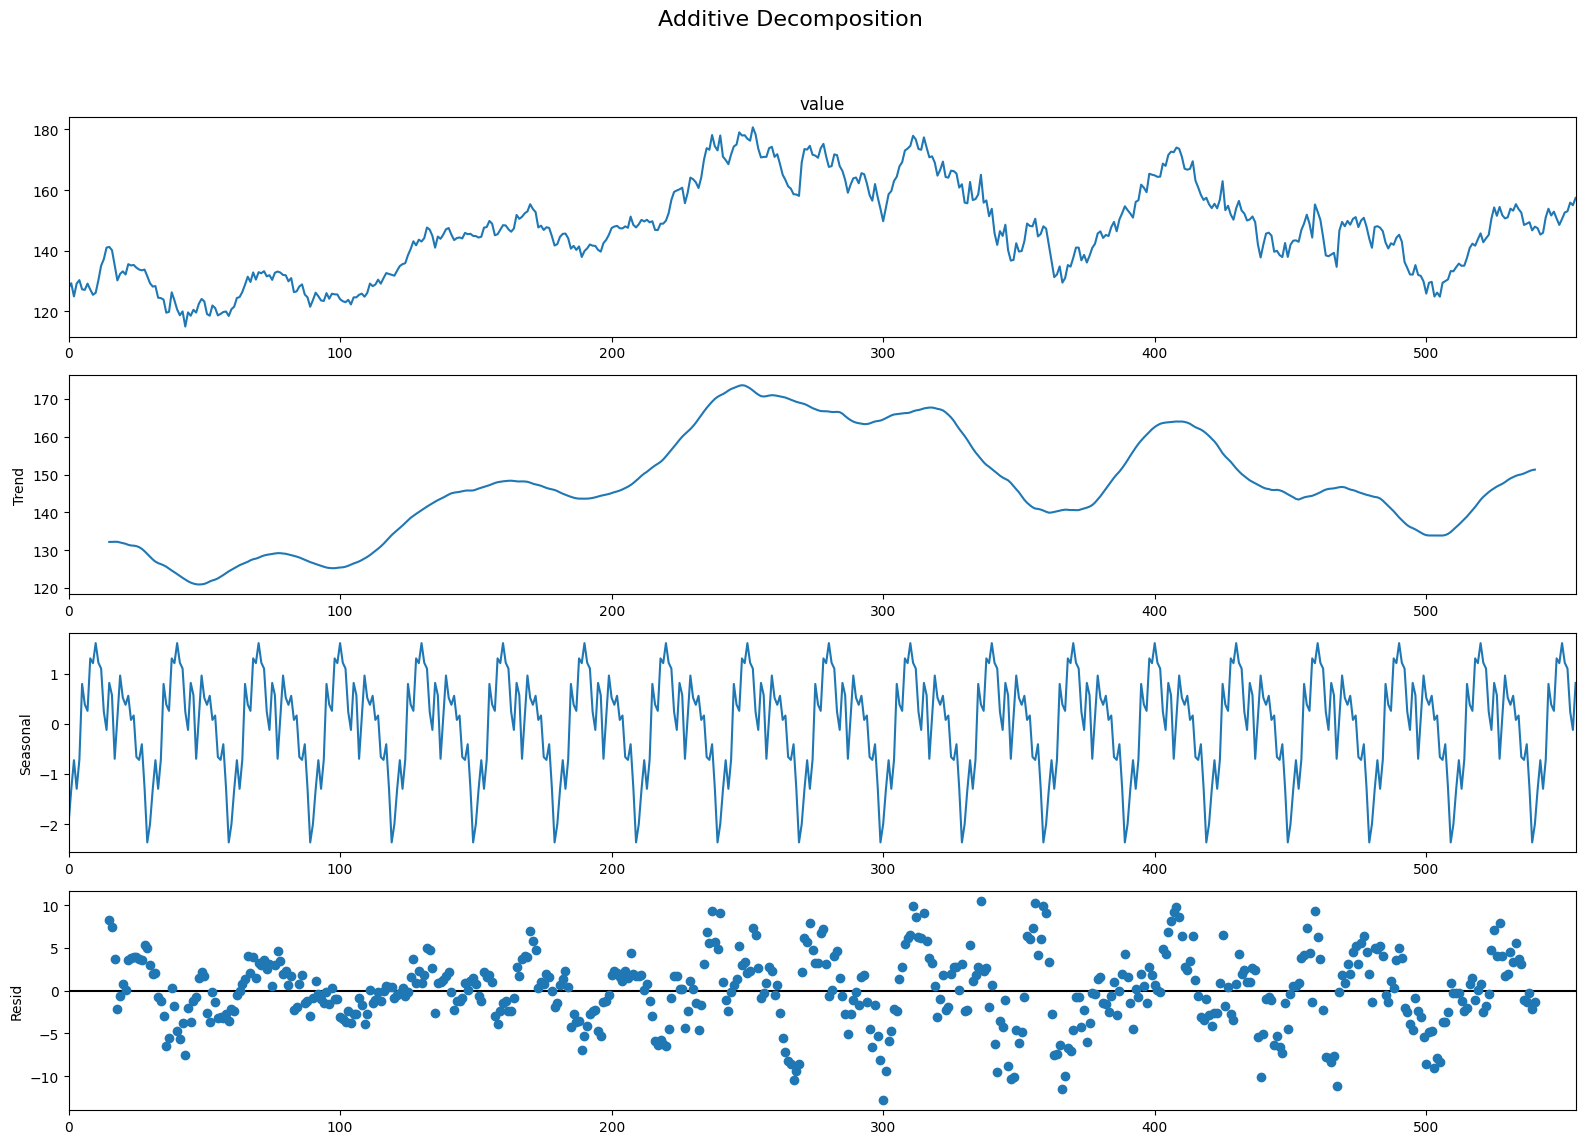

In [43]:
# Additive Decomposition
additive_decomposition = seasonal_decompose(apple_data['value'], model='additive', period=30)

# Plot
additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

# Time series analysis (TSA)

## Airline dataset

The airline passenger dataset shows the number of passengers per month from 1949 to 1960

In [11]:
airpass = sm.datasets.get_rdataset("AirPassengers", "datasets")

In [12]:
print(airpass.__doc__)

.. container::

   ============= ===============
   AirPassengers R Documentation
   ============= ===============

   .. rubric:: Monthly Airline Passenger Numbers 1949-1960
      :name: monthly-airline-passenger-numbers-1949-1960

   .. rubric:: Description
      :name: description

   The classic Box & Jenkins airline data. Monthly totals of
   international airline passengers, 1949 to 1960.

   .. rubric:: Usage
      :name: usage

   ::

      AirPassengers

   .. rubric:: Format
      :name: format

   A monthly time series, in thousands.

   .. rubric:: Source
      :name: source

   Box, G. E. P., Jenkins, G. M. and Reinsel, G. C. (1976) *Time Series
   Analysis, Forecasting and Control.* Third Edition. Holden-Day. Series
   G.

   .. rubric:: Examples
      :name: examples

   ::

      ## Not run: 
      ## These are quite slow and so not run by example(AirPassengers)

      ## The classic 'airline model', by full ML
      (fit <- arima(log10(AirPassengers), c(0, 1, 1),
     

In [13]:
airpass = pd.Series(airpass.data["value"])
airpass.index = pd.date_range(start = "1949-01", periods = len(airpass.index), freq = "M").to_period()
airpass.index = airpass.index.to_timestamp()

airpass = airpass.reset_index()
airpass.columns = ['date', 'passengers']
airpass = airpass.set_index('date')

airpass.head()

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


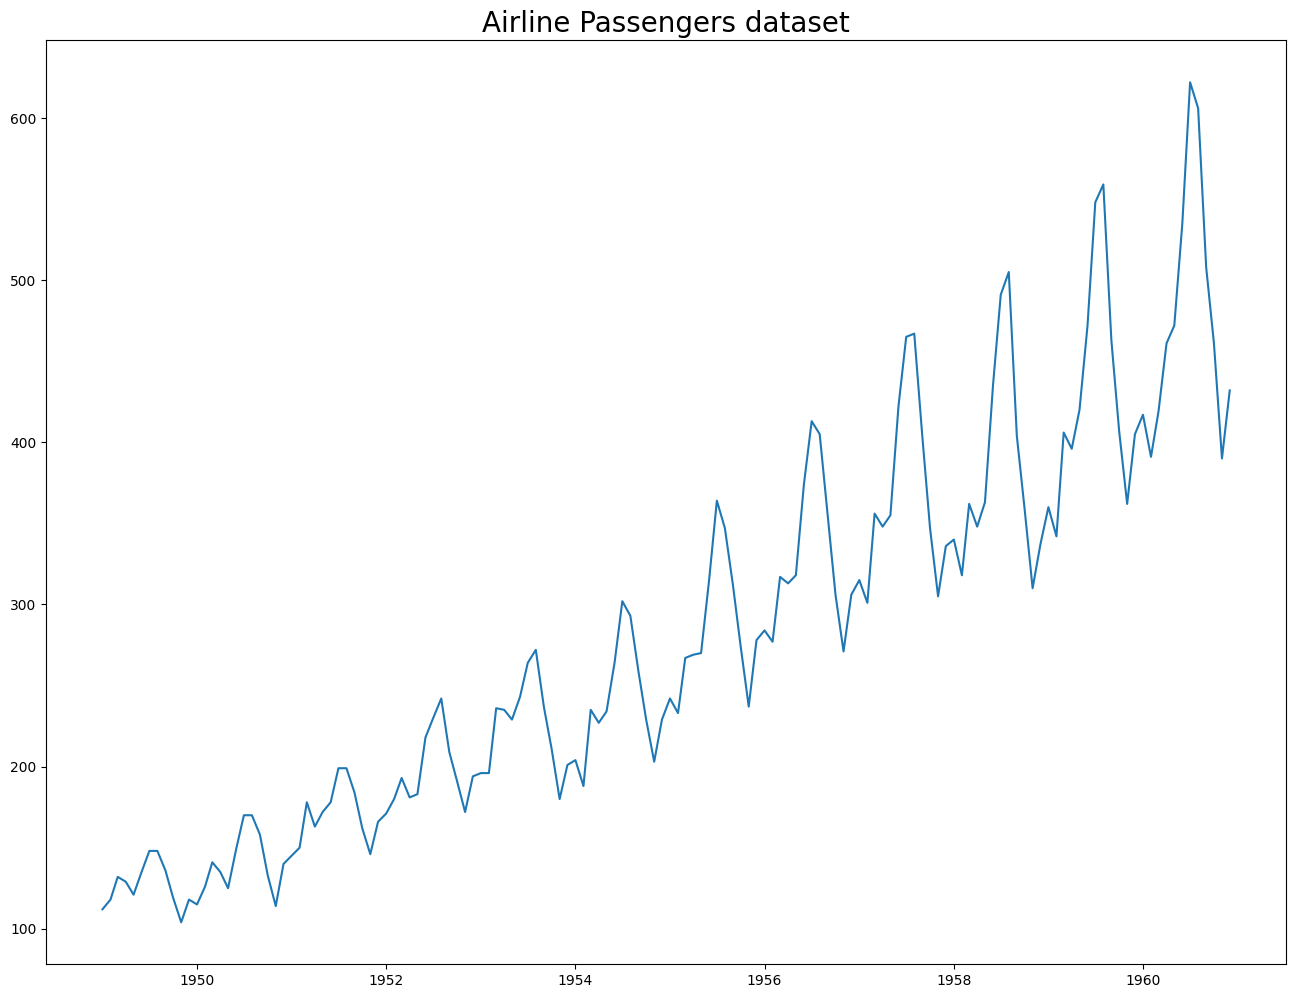

In [14]:
# Visualize
plt.title('Airline Passengers dataset', size=20)
plt.plot(airpass);

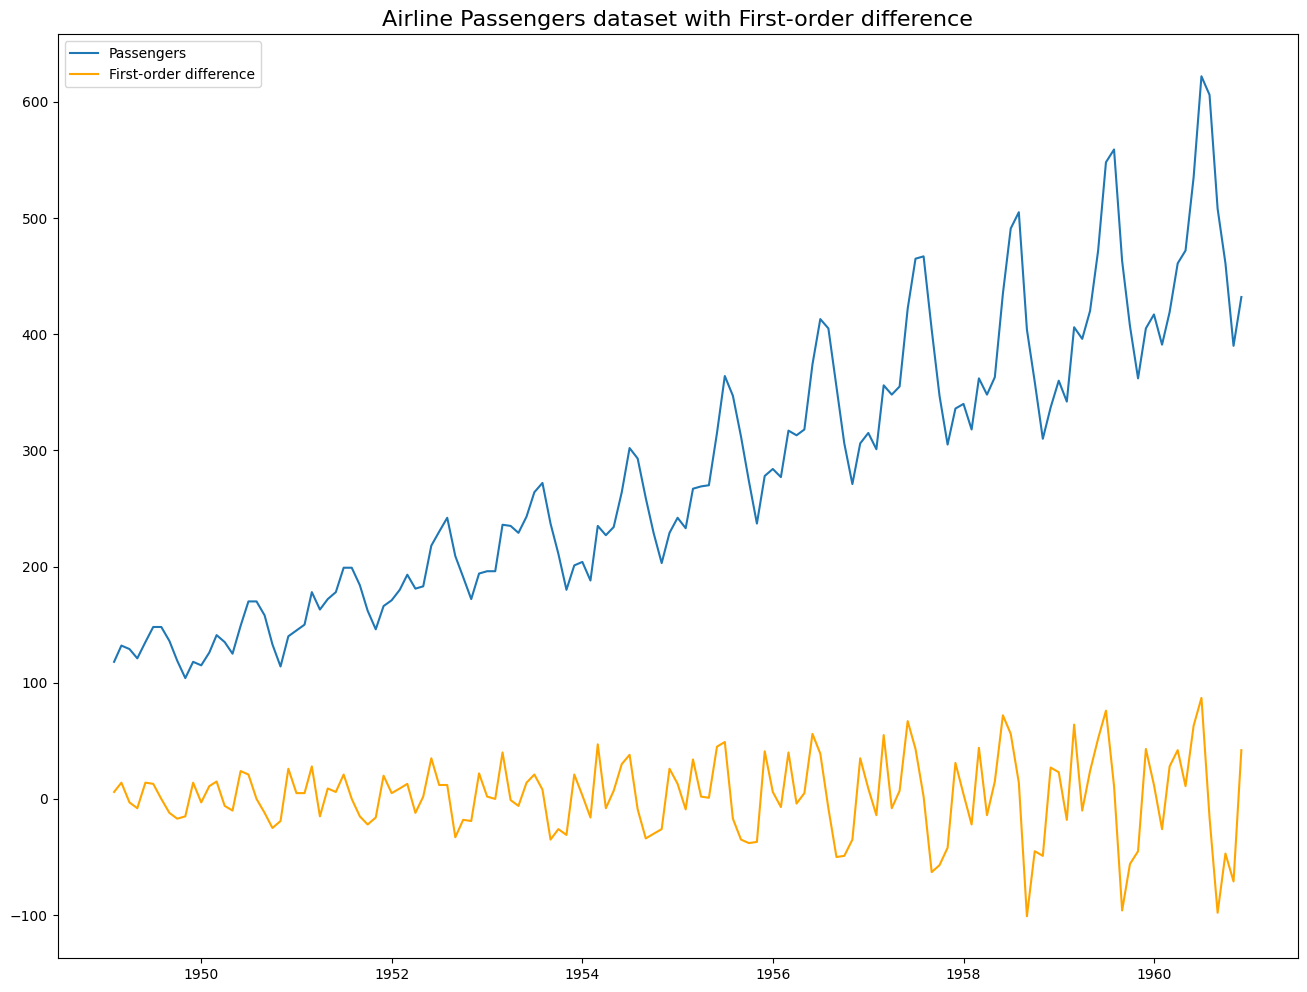

In [15]:
# First-order difference
airpass['passengers_diff'] = airpass['passengers'].diff(periods=1)
airpass = airpass.dropna()

# Plot
plt.title('Airline Passengers dataset with First-order difference', size=16)
plt.plot(airpass['passengers'], label='Passengers')
plt.plot(airpass['passengers_diff'], label='First-order difference', color='orange')
plt.legend();

In [16]:
airpass.head()

,passengers,passengers_diff
date,,
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0
1949-06-01,135,14.0


## Autocorrelation

Autocorrelation shows the correlation of a sequence with itself lagged by some number of time units. Once plotted, X-axis shows the lag number, and Y-axis shows the correlation of the sequence with a sequence at that lag. Y-axis ranges from -1 to 1.

Before calculating autocorrelation, you should make the time series stationary. In a nutshell — the mean, variance, and covariance shouldn’t change over time.

The easiest way to make time series stationary is by calculating the first-order difference.

In [82]:
df_lags

,original,lag_1
date,,
1949-02-01,6.0,6.0
1949-03-01,14.0,14.0
1949-04-01,-3.0,-3.0
1949-05-01,-8.0,-8.0
1949-06-01,14.0,14.0
...,...,...
1960-08-01,-16.0,-16.0
1960-09-01,-98.0,-98.0
1960-10-01,-47.0,-47.0


### Manual example

In [97]:
lags = 4
# lags_aux = lags -1
df_lags = pd.concat(
    [
        airpass.passengers_diff,
        airpass.passengers_diff.shift(periods=lags).dropna(),
    ],
    axis=1
)

df_lags.columns = ['original',f'lag_{lags}']

display(df_lags.head(lags+5))

df_lags.corr().applymap("{:.2f}".format)

,original,lag_4
date,,
1949-02-01,6.0,NaN
1949-03-01,14.0,NaN
1949-04-01,-3.0,NaN
1949-05-01,-8.0,NaN
1949-06-01,14.0,6.0
1949-07-01,13.0,14.0
1949-08-01,0.0,-3.0
1949-09-01,-12.0,-8.0
1949-10-01,-17.0,14.0


,original,lag_4
original,1.00,-0.32
lag_4,-0.32,1.00


In [89]:
acf_values = acf(airpass['passengers_diff'])
acf_values

array([ 1.        ,  0.30285526, -0.10214755, -0.24127349, -0.30040158,
       -0.09407271, -0.07844257, -0.0923622 , -0.29480158, -0.19177821,
       -0.10491707,  0.28293105,  0.82917786,  0.28450079, -0.10575172,
       -0.22213093, -0.23107603, -0.06227904, -0.06618505, -0.09039973,
       -0.29710958, -0.16273198])

In [19]:
np.round(acf_values,2)

array([ 1.  ,  0.3 , -0.1 , -0.24, -0.3 , -0.09, -0.08, -0.09, -0.29,
       -0.19, -0.1 ,  0.28,  0.83,  0.28, -0.11, -0.22, -0.23, -0.06,
       -0.07, -0.09, -0.3 , -0.16])

The first value is 1, because a correlation between two identical series was calculated. But take a look at as 12th period — autocorrelation value is 0.83. This tells you a value 12 periods ago has a strong impact on the value today.

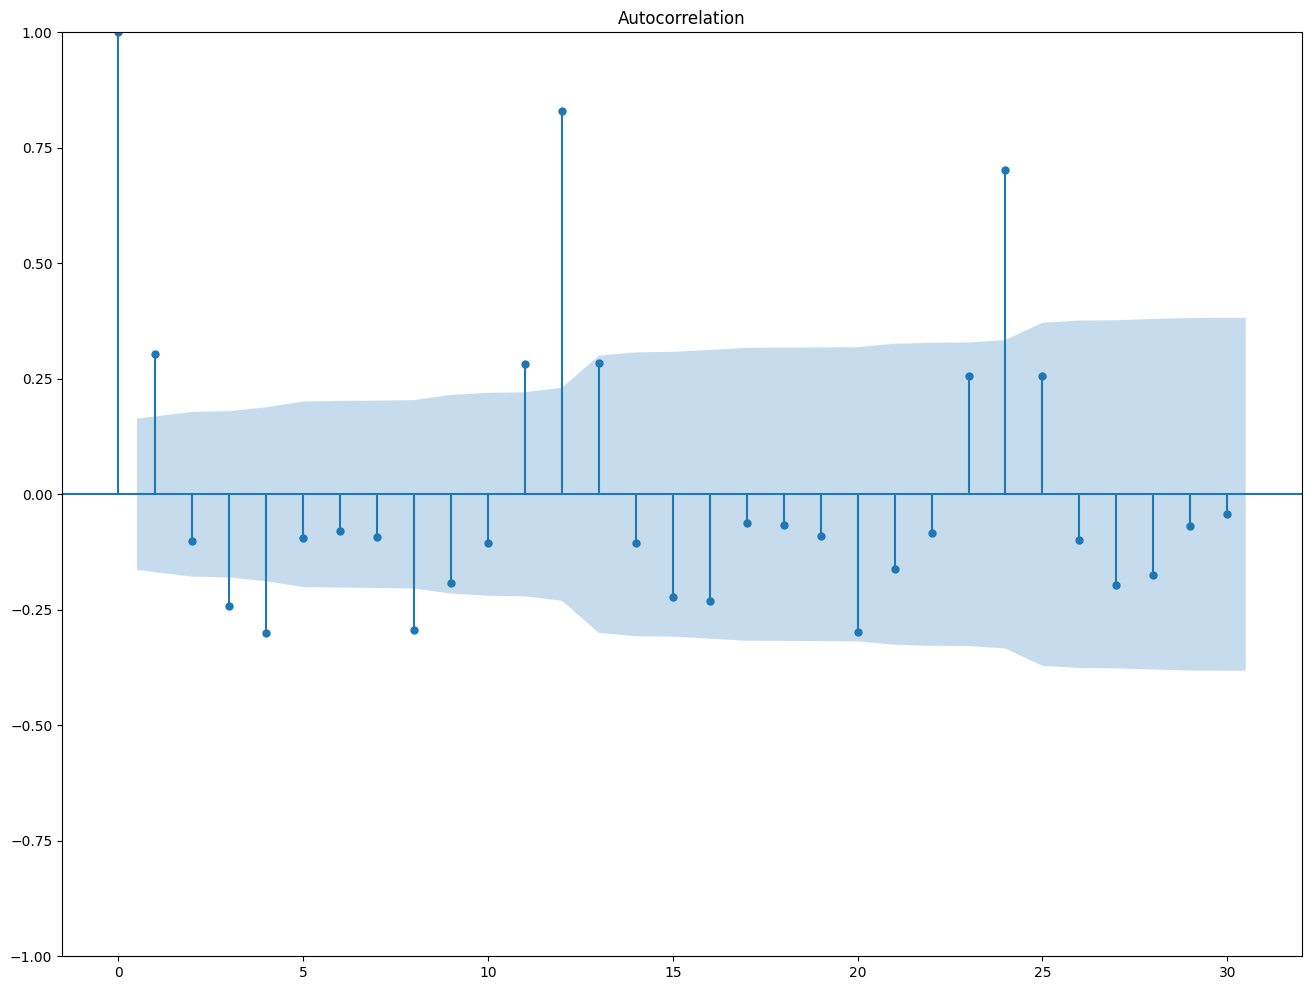

In [20]:
plot_acf(airpass['passengers_diff'], lags=30);

The plot confirms our assumption about the correlation on lag 12. The same is visible at lag 24, but the correlation declines over time. Value 12 periods ago has more impact on the value today than value 24 periods ago does.
Another thing to note is the shaded area. Anything inside it isn’t statistically significant.

## PACF

*Partial autocorrelation*

It does the same as regular autocorrelation — shows the correlation of a sequence with itself lagged by some number of time units. But there’s a twist. Only the direct effect is shown, and all intermediary effects are removed.


The partial autocorrelation function (PACF) gives the partial correlation of a stationary time series with its own lagged values, regressed the values of the time series at all shorter lags. It contrasts with the autocorrelation function, which does not control for other lags.

This is the critical difference between Autocorrelation and Partial Autocorrelation — the inclusion or exclusion of indirect correlations in the calculation.

In [21]:
pacf_values = pacf(airpass['passengers_diff'])
np.round(pacf_values,2)

array([ 1.  ,  0.3 , -0.22, -0.16, -0.23,  0.01, -0.2 , -0.16, -0.49,
       -0.28, -0.67, -0.42,  0.61, -0.05, -0.3 ,  0.02,  0.14,  0.09,
       -0.12,  0.01, -0.22, -0.12])

In [105]:
help(plot_pacf)

Help on function plot_pacf in module statsmodels.graphics.tsaplots:

plot_pacf(x, ax=None, lags=None, alpha=0.05, method=None, use_vlines=True, title='Partial Autocorrelation', zero=True, vlines_kwargs=None, **kwargs)
    Plot the partial autocorrelation function
    
    Parameters
    ----------
    x : array_like
        Array of time-series values
    ax : AxesSubplot, optional
        If given, this subplot is used to plot in instead of a new figure being
        created.
    lags : {int, array_like}, optional
        An int or array of lag values, used on horizontal axis. Uses
        np.arange(lags) when lags is an int.  If not provided,
        ``lags=np.arange(len(corr))`` is used.
    alpha : float, optional
        If a number is given, the confidence intervals for the given level are
        returned. For instance if alpha=.05, 95 % confidence intervals are
        returned where the standard deviation is computed according to
        1/sqrt(len(x))
    method : str
       

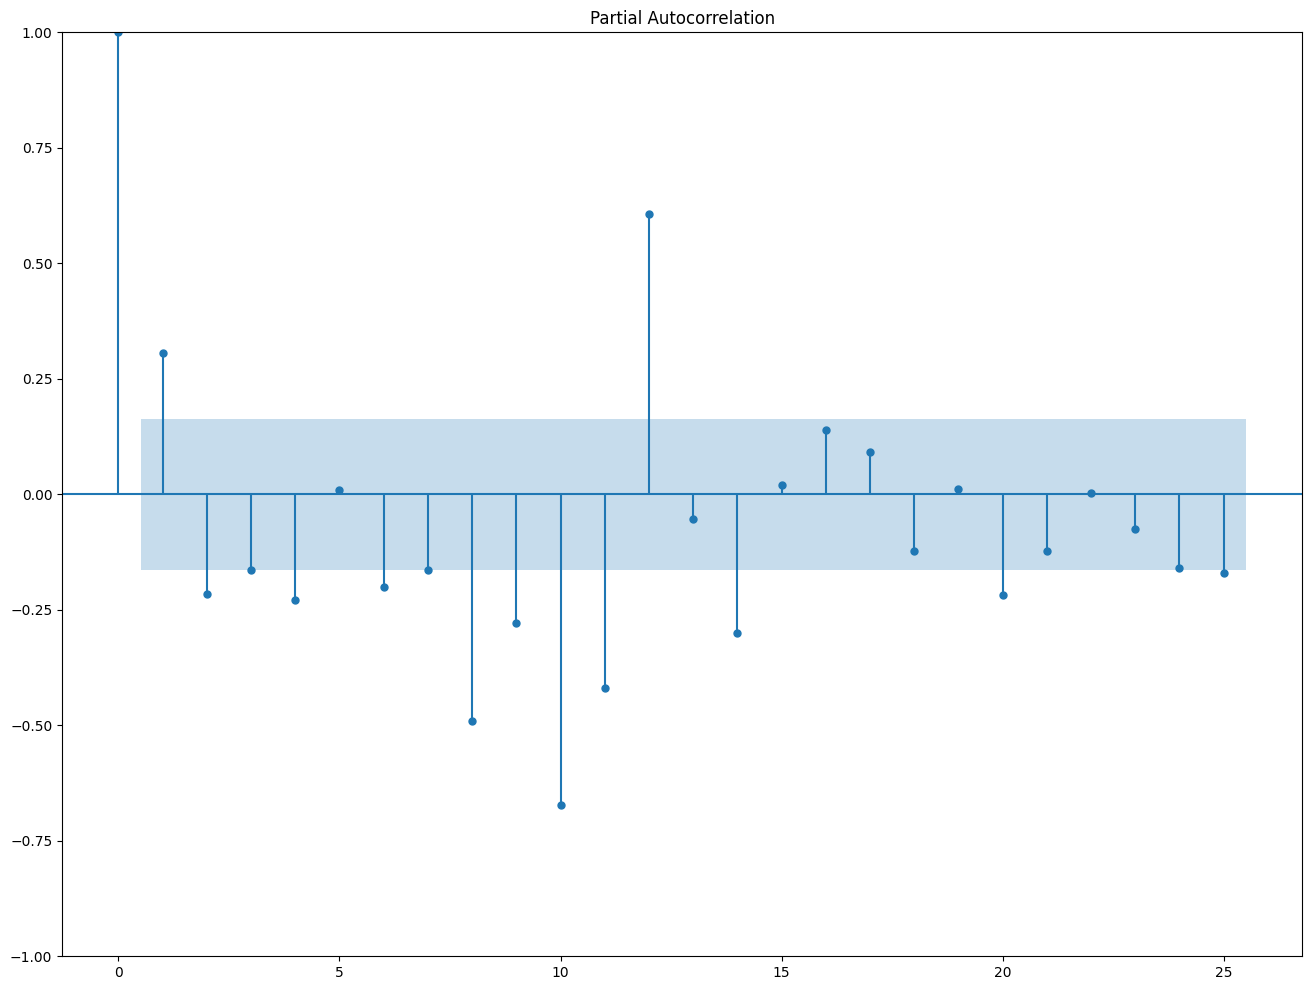

In [109]:
plot_pacf(
    airpass['passengers_diff'], 
    lags=25,
    # method='yw'
    
);

## ACF and PACF plots

*How to interpret plots*

Time series models you’ll soon learn about, such as Auto Regression (AR), Moving Averages (MA), or their combinations (ARMA), require you to specify one or more parameters. These can be obtained by looking at ACF and PACF plots.
In a nutshell:
* If the ACF plot declines gradually and the PACF drops instantly, use Auto Regressive model.
* If the ACF plot drops instantly and the PACF declines gradually, use Moving Average model.
* If both ACF and PACF decline gradually, combine Auto Regressive and Moving Average models (ARMA).
* If both ACF and PACF drop instantly (no significant lags), it’s likely you won’t be able to model the time series.

Still, reading ACF and PACF plots is challenging, and you’re far better of using grid search to find optimal parameter values. An optimal parameter combination has the lowest error (such as MAPE) or lowest general quality estimator (such as AIC). We’ll cover time series evaluation metrics soon, so stay tuned.

# White noise

White noise is the first Time Series Model (TSM) we need to understand. By definition a time series that is a white noise process has serially UNcorrelated errors and the expected mean of those errors is equal to zero. Another description for serially uncorrelated errors is, independent and identically distributed (i.i.d.). This is important because, if our TSM is appropriate and successful at capturing the underlying process, the residuals of our model will be i.i.d. and resemble a white noise process. Therefore part of TSA is literally trying to fit a model to the time series such that the residual series is indistinguishable from white noise.

In [23]:
def tsplot(y, lags=None, figsize=(10, 8), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        #mpl.rcParams['font.family'] = 'Ubuntu Mono'
        layout = (3, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        qq_ax = plt.subplot2grid(layout, (2, 0))
        pp_ax = plt.subplot2grid(layout, (2, 1))
        
        y.plot(ax=ts_ax)
        ts_ax.set_title('Time Series Analysis Plots')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5, )
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5, method='yw')
        sm.qqplot(y, line='s', ax=qq_ax)
        qq_ax.set_title('QQ Plot')        
        scs.probplot(y, sparams=(y.mean(), y.std()), plot=pp_ax)

        plt.tight_layout()
    return 

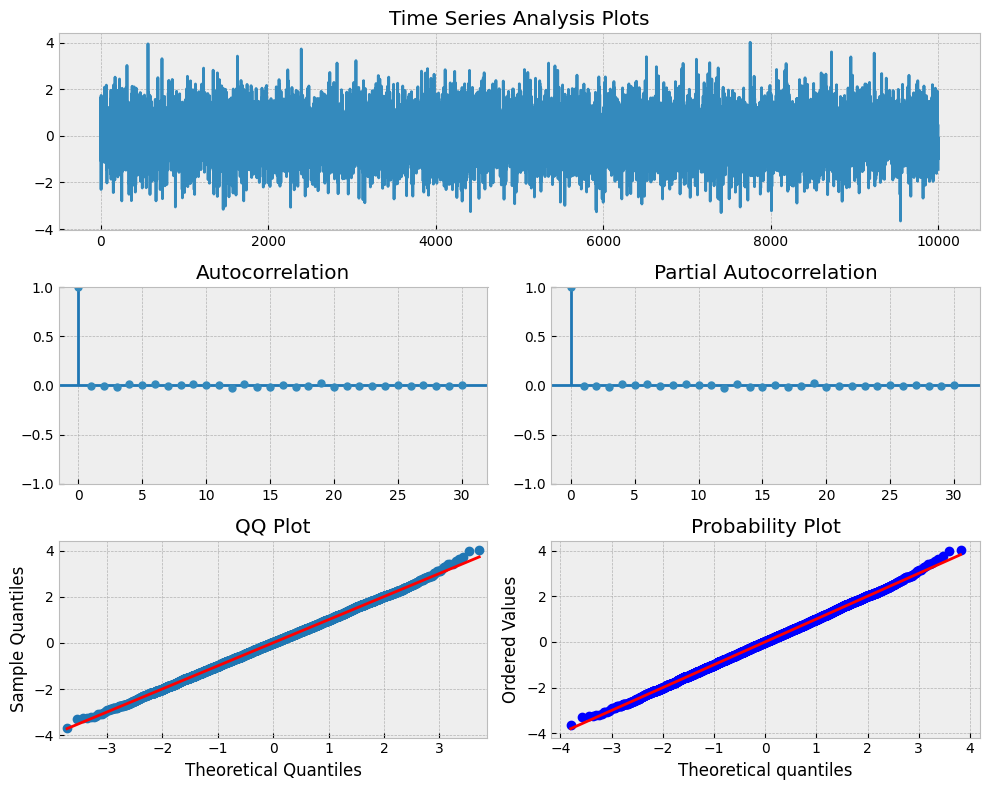

In [24]:
np.random.seed(1)

# plot of discrete white noise
randser = np.random.normal(size=10000)
tsplot(randser, lags=30)

We can see that process appears to be random and centered about zero. The autocorrelation (ACF) and partial autocorrelation (PACF) plots also indicate no significant serial correlation. Keep in mind we should see approximately 5% significance in the autocorrelation plots due to pure chance as a result of sampling from the Normal distribution. Below that we can see the QQ and Probability Plots, which compares the distribution of our data with another theoretical distribution. In this case, that theoretical distribution is the standard normal distribution. Clearly our data is distributed randomly, and appears to follow Gaussian (Normal) white noise, as it should.

In [25]:
print(
f"""
Random Series
--------------
mean: {randser.mean():.3f}
variance: {randser.var():.3f}
standard deviation: {randser.std():.3f}
"""
)


Random Series
--------------
mean: 0.010
variance: 0.998
standard deviation: 0.999



# Random walk

A random walk is a random process that describes a path that consists of a succession of random steps on some mathematical space.
An elementary example of a random walk is the random walk on the integer number line Z which starts at 0, and at each step moves +1 or −1 with equal probability. Other examples include the path traced by a molecule as it travels in a liquid or a gas, the search path of a foraging animal, or the price of a fluctuating stock and the financial status of a gambler.

The significance of a random walk is that it is non-stationary because the covariance between observations is time-dependent. If the TS we are modeling is a random walk it is unpredictable.

Let's simulate a random walk:

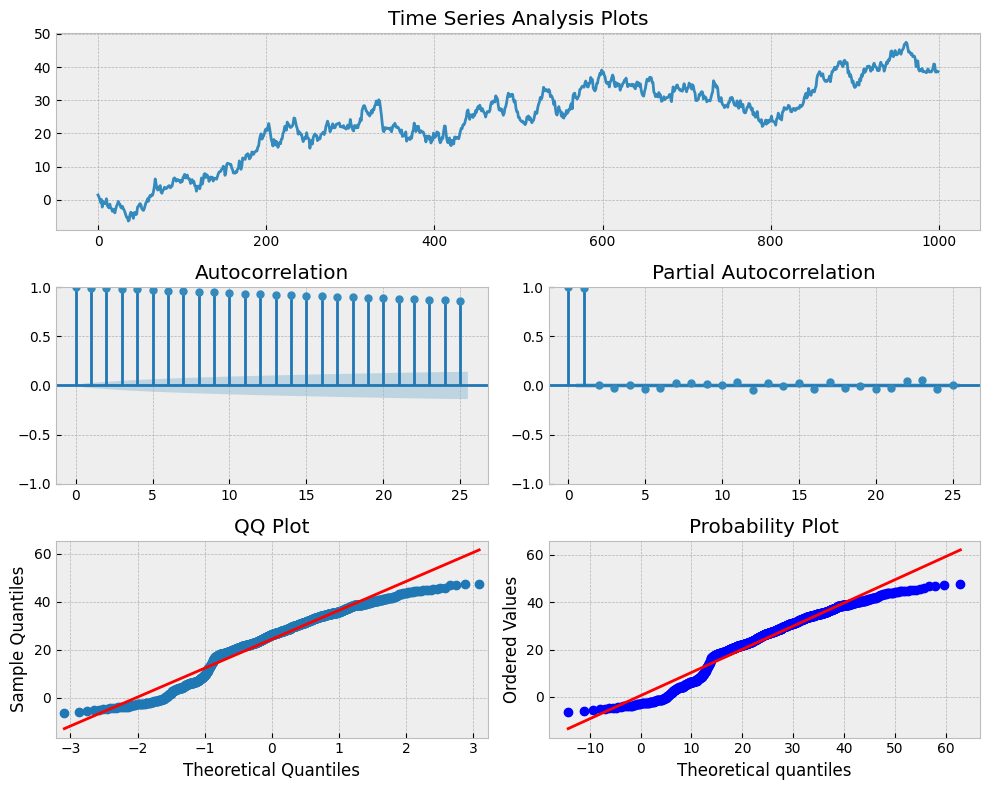

In [26]:
np.random.seed(1)
n_samples = 1000

x = w = np.random.normal(size=n_samples)
for t in range(n_samples):
    x[t] = x[t-1] + w[t]

_ = tsplot(x, lags=25)

Clearly our TS is not stationary. Let's find out if the random walk model is a good fit for our simulated data. Recall that a random walk is $x_{t} = x_{t-1} + w_{t}$. Using algebra we can say that  $x_{t} - x_{t-1} = w_{t}$. Thus the first differences of our random walk series should equal a white noise process!

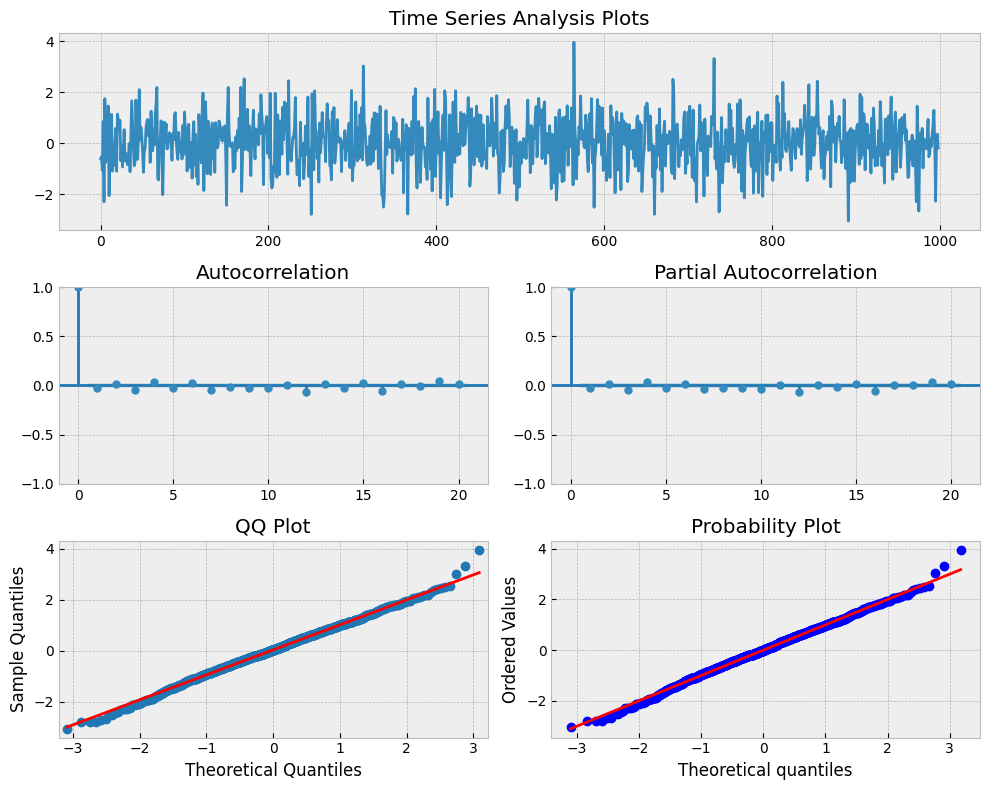

In [27]:
_ = tsplot(np.diff(x), lags=20)

Our definition holds as this looks exactly like a white noise process

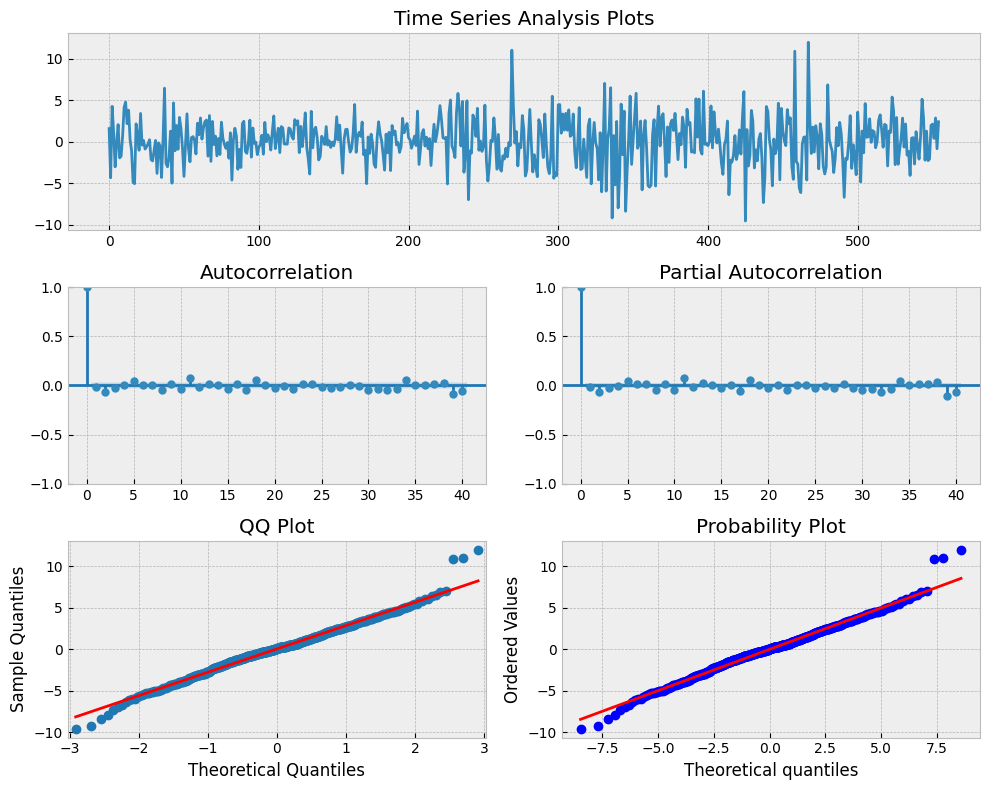

In [28]:
_ = tsplot(np.diff(apple_data.value), lags=40)

It's quite similar to white noise. However, notice the shape of the QQ and Probability plots. This indicates that the process is close to normality but with 'heavy tails'. There also appears to be some significant serial correlation in the ACF, and PACF plots around lags 1, 5?, 16?, 18 and 21. This means that there should be better models to describe the actual price change process. 

# Linear Models

Linear models aka trend models represent a TS that can be graphed using a straight line. The basic equation is:


$$
y_{t} = \beta_{0} + \beta_{1}t + \epsilon_{t}
$$

In this model the value of the dependent variable is determined by the beta coefficients and a singular independent variable, time.


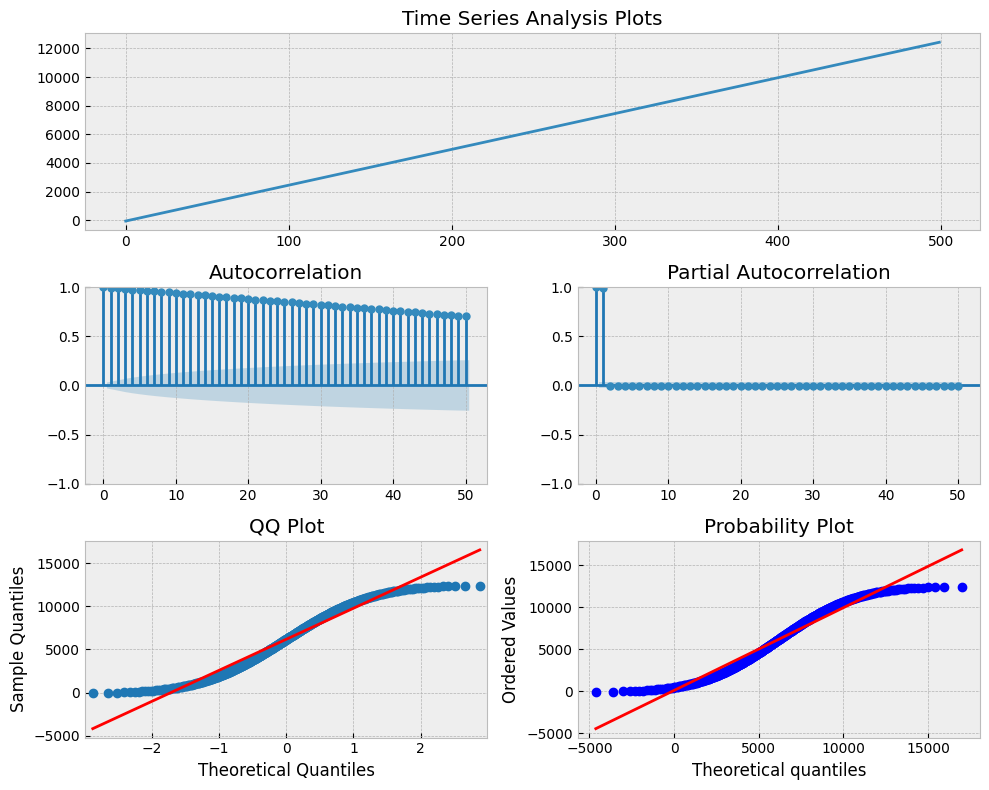

In [29]:
w = np.random.randn(500)
y = np.empty_like(w)

b0 = -50.
b1 = 25.
for t in range(len(w)):
    y[t] = b0 + b1*t + w[t]
    
_ = tsplot(y, lags=50)  

Here we can see that the residuals of the model are correlated and linearly decreasing as a function of the lag. The distribution is approximately normal. Before using this model to make predictions we would have to account for and remove the obvious autocorrelation present in the series. The significance of the PACF at lag 1 indicates that an autoregressive model may be appropriate.

# Log-Linear Models

These models are similar to linear models except that the data points form an exponential function that represent a constant rate of change with respect to each time step. For example, firm ABC's sales increasing X% at each time step. When plotting the simulated sales data you get a curve that looks like this:

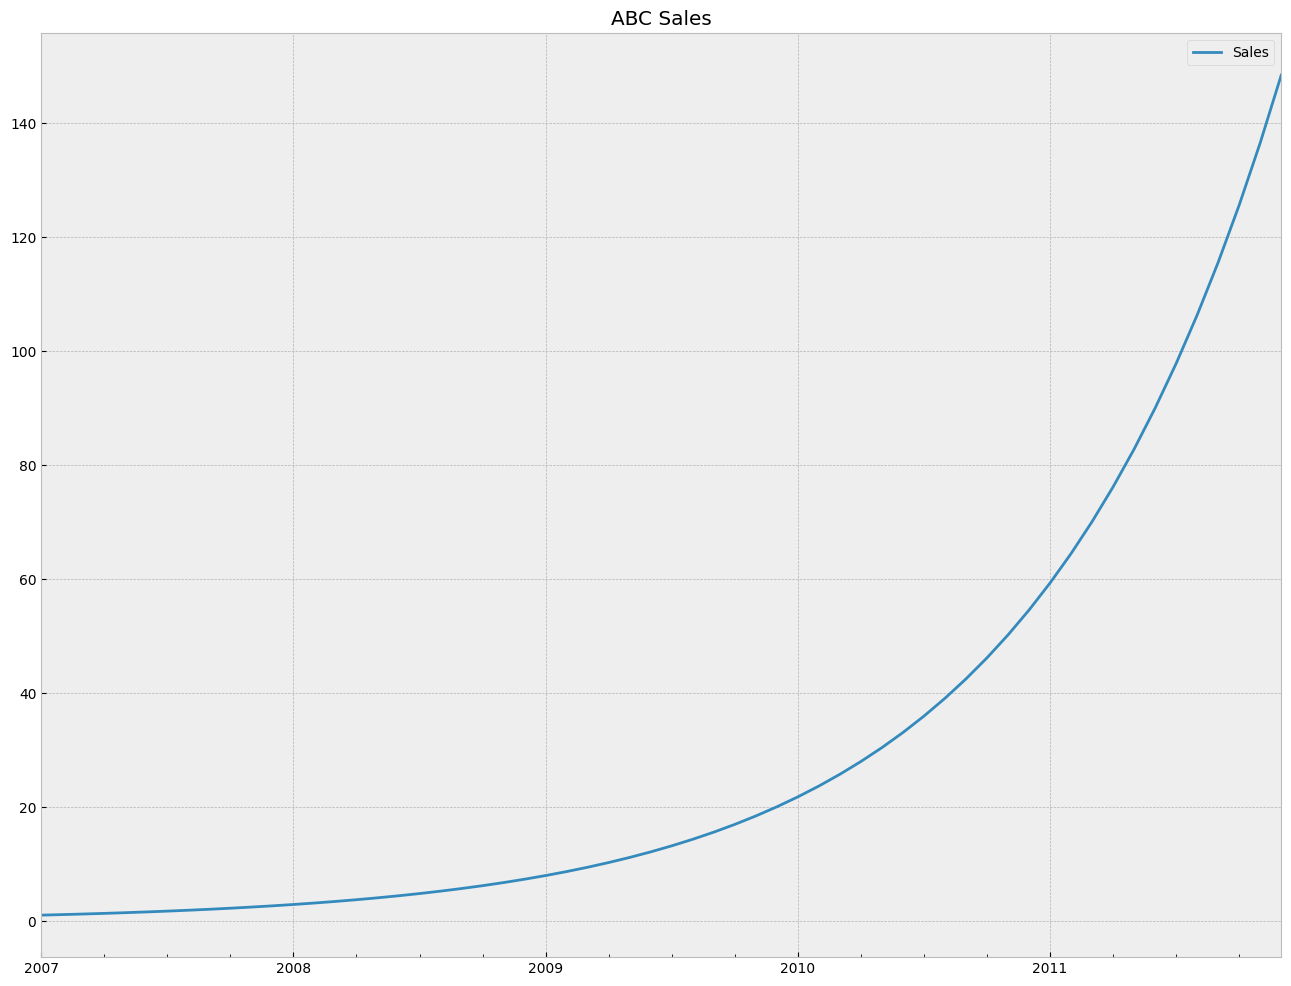

In [30]:
# Simulate ABC exponential growth

# fake dates
idx = pd.date_range('2007-01-01', '2012-01-01', freq='M')

# fake sales increasing at exponential rate
sales = [np.exp( x/12 ) for x in range(1, len(idx)+1)]

# create dataframe and plot
df = pd.DataFrame(sales, columns=['Sales'], index=idx)

with plt.style.context('bmh'):
    df.plot()
    plt.title('ABC Sales')

In [31]:
df.head()

,Sales
2007-01-31,1.086904
2007-02-28,1.181360
2007-03-31,1.284025
2007-04-30,1.395612
2007-05-31,1.516897


In [32]:
df.tail()

,Sales
2011-08-31,106.342675
2011-09-30,115.584285
2011-10-31,125.629027
2011-11-30,136.546698
2011-12-31,148.413159


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2007-01-31 to 2011-12-31
Freq: M
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   60 non-null     float64
dtypes: float64(1)
memory usage: 960.0 bytes


We can then transform the data by taking the natural logarithm of sales. Now a linear regression is a much better fit to the data.


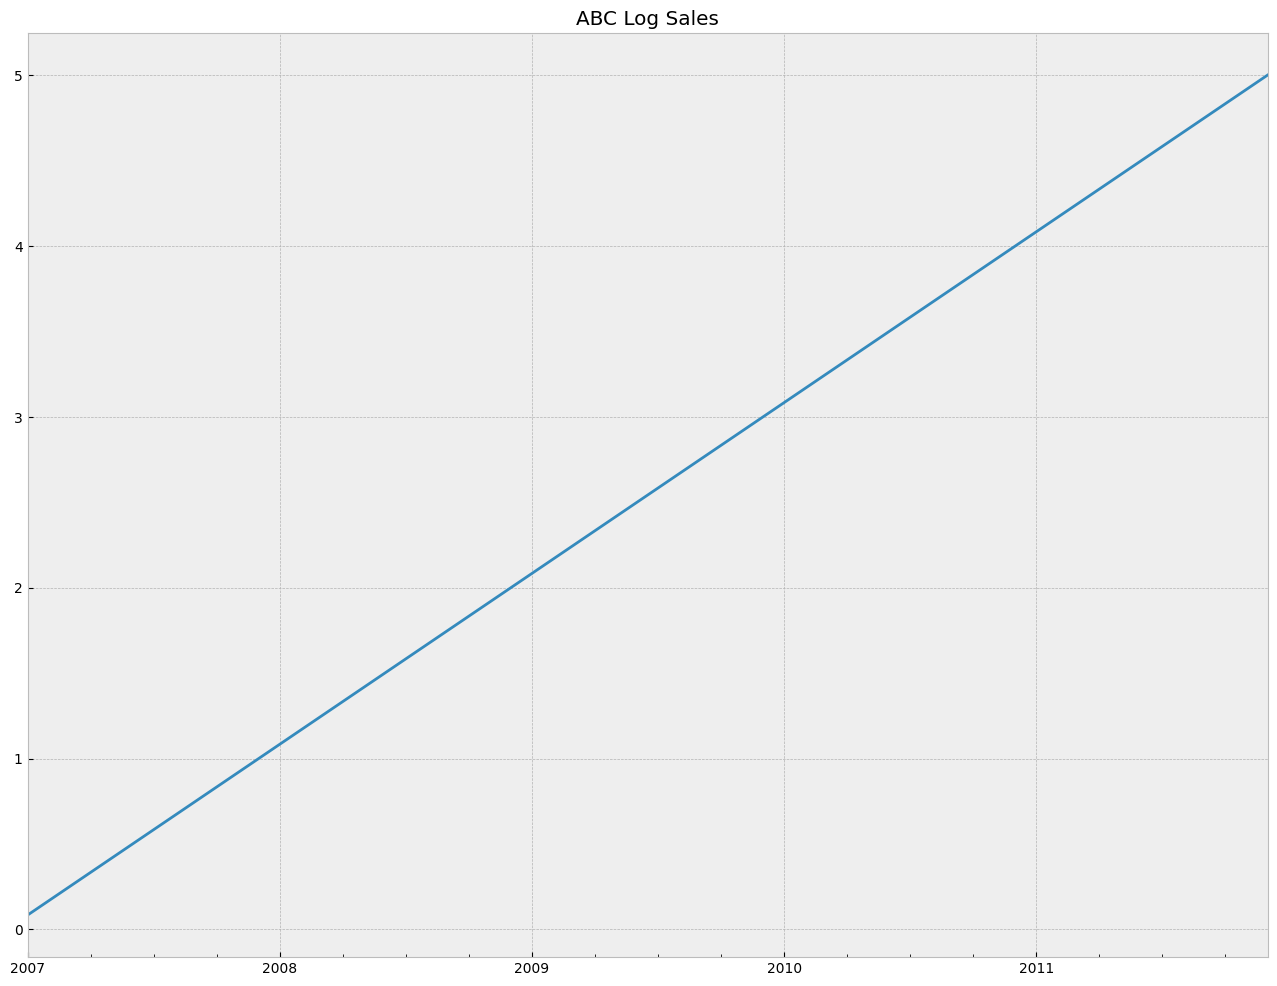

In [34]:
# ABC log sales 

with plt.style.context('bmh'):
    pd.Series(np.log(sales), index=idx).plot()
    plt.title('ABC Log Sales')

These models have a fatal weakness as discussed previously. They assume serially UNcorrelated errors, which as we have seen in the linear model example is not true. In real life, TS data usually violates our stationary assumptions which motivates our progression to autoregressive models.

# AR(p)

*Autoregressive Models*

When the dependent variable is regressed against one or more lagged values of itself the model is called autoregressive. The formula looks like this:

$$
x_{t} = \alpha_{1}x_{t-1} + ... +  \alpha_{p}x_{t-p} + \omega_{t}
$$

When you describe the "order" of the model, as in, an AR model of order "p", the p represents the number of lagged variables used within the model. For example an AR(2) model or second-order autoregressive model looks like this:

$$
x_{t} = \alpha_{1}x_{t-1} + \alpha_{2}x_{t-2} + \omega_{t}
$$

Here, alpha is the coefficient, and omega is a white noise term. Alpha cannot equal zero in an AR model. Note that an AR(1) model with alpha set equal to 1 is a random walk and therefore not stationary. 

$$
x_{t} = 1x_{t-1} + \omega_{t}
$$

Let's simulate an AR(1) model with alpha set equal to 0.6

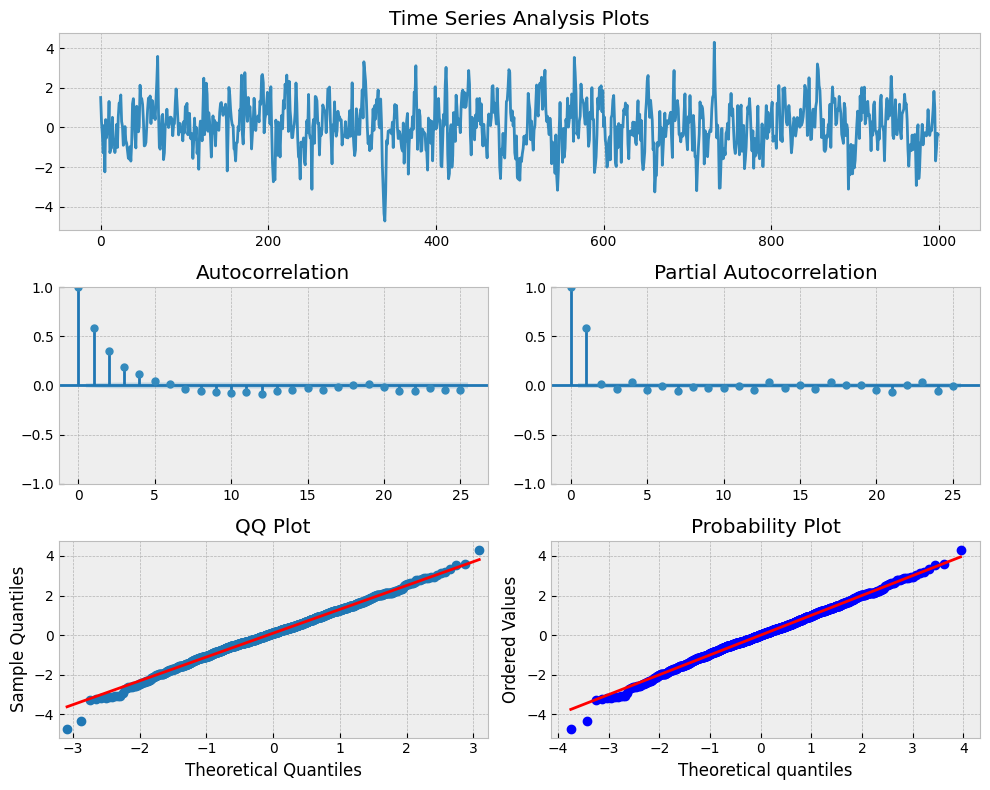

In [35]:
# Simulate an AR(1) process with alpha = 0.6

np.random.seed(1)
n_samples = int(1000)
a = 0.6
x = w = np.random.normal(size=n_samples)

for t in range(n_samples):
    x[t] = a*x[t-1] + w[t]
    
_ = tsplot(x, lags=25)

As expected the distribution of our simulated AR(1) model is normal. There is significant serial correlation between lagged values especially at lag 1 as evidenced by the PACF plot. 

Now we can fit an AR(p) model using Python's statsmodels. First we fit the AR model to our simulated data and return the estimated alpha coefficient. Then we use the statsmodels function "select_order()" to see if the fitted model will select the correct lag. If the AR model is correct the estimated alpha coefficient will be close to our true alpha of 0.6 and the selected order will equal 1.

In [36]:
# Fit an AR(p) model to simulated AR(1) model with alpha = 0.6

mdl = AutoReg(x, lags=1, trend='t').fit()
est_order = ar_select_order(
    x,
    maxlag=30, ic='aic', trend='t'
)

true_order = 1
print(
f'''
alpha estimate: {mdl.params[1]:3.5f} | best lag order = {est_order.ar_lags}
'''
)

print(
f'''
true alpha: {a:3.5f} | true order = {true_order}
'''
)

# print('\ntrue alpha = {} | true order = {}'
#   .format(a, true_order))


alpha estimate: 0.58112 | best lag order = [1]


true alpha: 0.60000 | true order = 1



Looks like we were able to recover the underlying parameters of our simulated data. Let's simulate an AR(2) process with alpha_1 = 0.666 and alpha_2 = -0.333. For this we make use of statsmodel's "arma_generate_samples()" function. This function allows us to simulate an AR model of arbitrary orders. Note that there are some peculiarities of Python's version which requires us to take some extra steps before using the function.

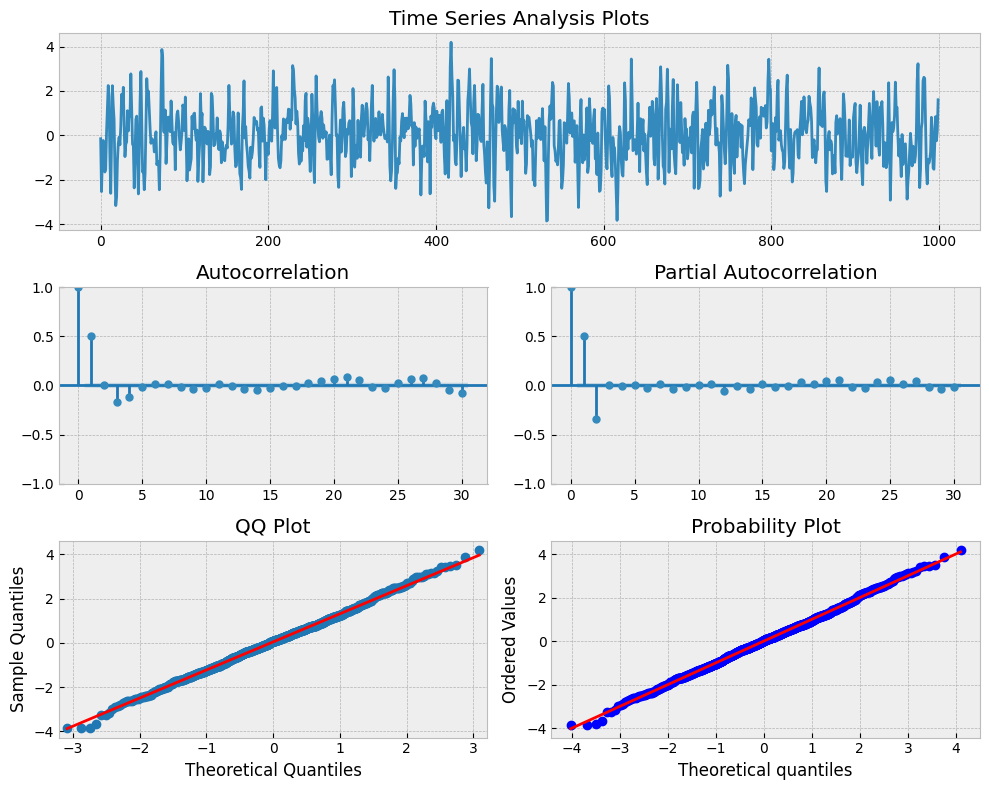

In [37]:
# Simulate an AR(2) process

n = int(1000)
alphas = np.array([.666, -.333])
betas = np.array([0.])

# Python requires us to specify the zero-lag value which is 1
# Also note that the alphas for the AR model must be negated
# We also set the betas for the MA equal to 0 for an AR(p) model
# For more information see the examples at statsmodels.org
ar = np.r_[1, -alphas]
ma = np.r_[1, betas]

ar2 = smt.arma_generate_sample(ar=ar, ma=ma, nsample=n) 
_ = tsplot(ar2, lags=30)

In [38]:
mdl = AutoReg(ar2, lags=2, trend='t').fit()
est_order = ar_select_order(
    ar2,
    maxlag=30, ic='aic', trend='t'
)

true_order = 2
print(
f'''
alpha estimate: {mdl.params[1:]:} | best lags order = {est_order.ar_lags}
'''
)

print(
f'''
true alpha: {[.666, -.333]} | true order = {true_order}
'''
)


alpha estimate: [ 0.67589852 -0.33936447] | best lags order = [1, 2]


true alpha: [0.666, -0.333] | true order = 2



In [55]:
pip freeze | grep stat

statsmodels==0.13.5
Note: you may need to restart the kernel to use updated packages.


## Apple data

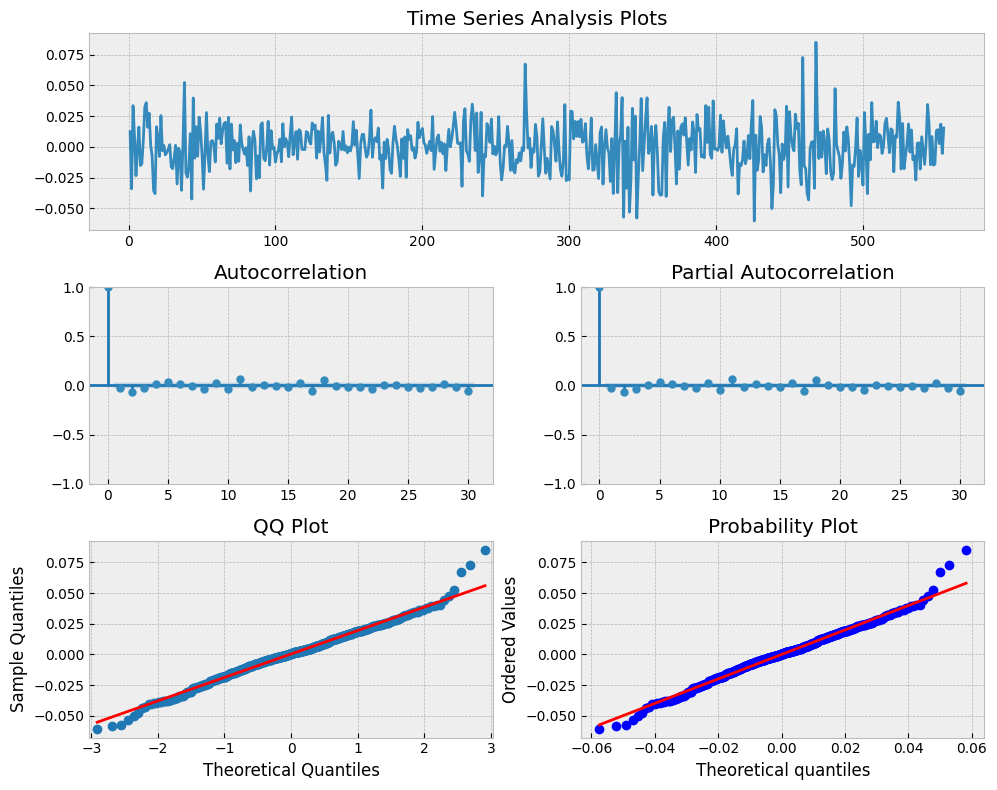

In [39]:
_ = tsplot(apple_data.log_returns.dropna() , lags=30)

In [40]:
est_order = ar_select_order(
    apple_data.log_returns.dropna().values,
    maxlag=13, ic='aic', trend='t', glob=True
)

In [41]:
est_order.ar_lags

[2, 11]

# MA(q)

*Moving Average Models*

The moving-average model (MA model), also known as moving-average process, is a common approach for modeling univariate time series. The moving-average model specifies that the output variable is cross-correlated with a non-identical to itself random-variable.

MA(q) models are very similar to AR(p) models. The difference is that the MA(q) model is a linear combination of past white noise error terms as opposed to a linear combo of past observations like the AR(p) model. The motivation for the MA model is that we can observe "shocks" in the error process directly by fitting a model to the error terms. In an AR(p) model these shocks are observed indirectly by using the ACF on the series of past observations. The formula for an MA(q) model is:

$$
x_{t} = \omega_{t} + \beta_{1}\omega_{t-1} + ... +  \beta_{q}\omega_{t-q} = \omega_{t} + \sum_{i=1}^{Q} \beta_{i}\omega_{t-i}
$$

$\omega$ is white noise with $E(w_{t})$ = 0 and variance of $\sigma^{2}$. Let's simulate this process using beta=0.6 and specifying the AR(p) alpha equal to 0.

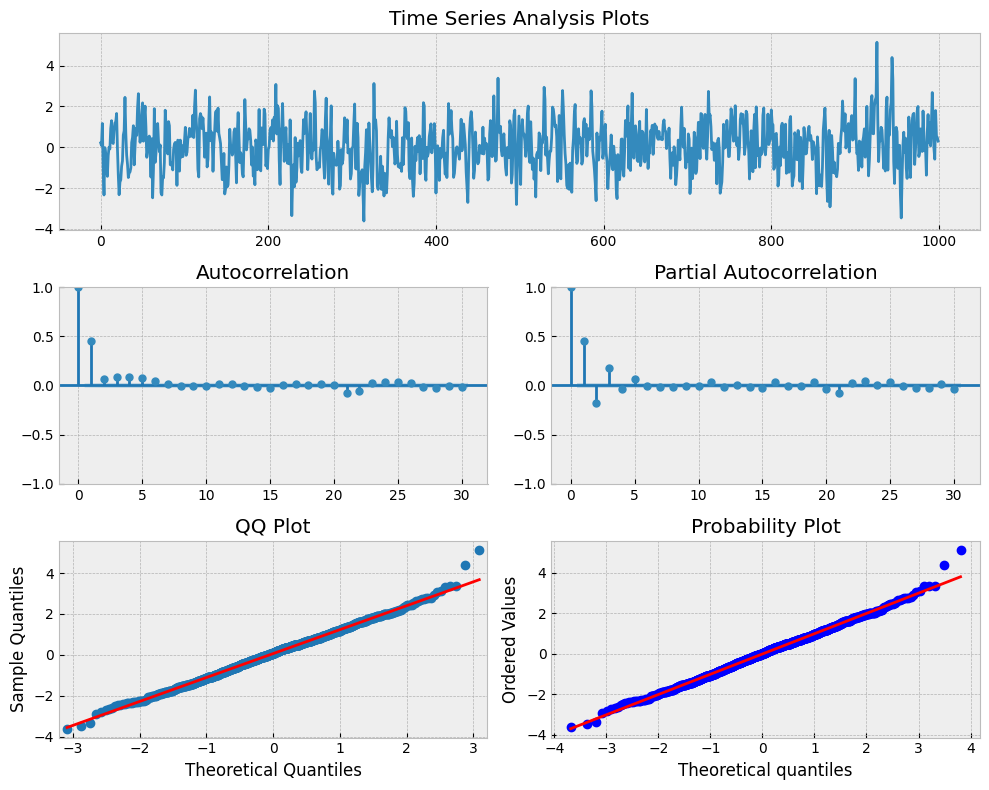

In [110]:
# Simulate an MA(1) process

n = int(1000)

# set the AR(p) alphas equal to 0
alphas = np.array([0.])
betas = np.array([0.6])

# add zero-lag and negate alphas
ar = np.r_[1, -alphas]
ma = np.r_[1, betas]

ma1 = smt.arma_generate_sample(ar=ar, ma=ma, nsample=n) 
_ = tsplot(ma1, lags=30)

The ACF function shows that lag 1 is significant which indicates that a MA(1) model may be appropriate for our simulated series.

In [111]:
mdl = ARIMA(
    ma1,
    order=(0, 0, 1),
    trend = "n",
    seasonal_order = (0,0,0,0)
).fit()
mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1431.051
Date:                Wed, 22 Mar 2023   AIC                           2866.101
Time:                        18:57:34   BIC                           2875.917
Sample:                             0   HQIC                          2869.832
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.5717      0.025     23.117      0.000       0.523       0.620
sigma2         1.0241      0.043     23.960      0.000       0.940       1.108
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 4.91
Prob(Q):                              0.69   Prob(JB):                         0.09
Heteroskedasticity (H):               0.96   Skew:                             0.08
Prob(H) (two-sided):                  0.70   Kurtosis:                         3.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The model was able to correctly estimate the lag coefficent as 0.58 is close to our true value of 0.6. Also notice that our 95% confidence interval does contain the true value.

# ARMA(p, q)

*Autoregressive Moving Average Models*

The ARMA model is simply the merger between AR(p) and MA(q) models.

AR(p) models try to capture (explain) the momentum and mean reversion effects often observed in trading markets.

MA(q) models try to capture (explain) the shock effects observed in the white noise terms. These shock effects could be thought of as unexpected events affecting the observation process

ARMA's weakness is that it ignores the volatility clustering effects found in most financial time series. 

The model formula is:

$$
x_{t} = \alpha_{1}x_{t-1} + \alpha_{2}x_{t-2} + ... +  \omega_{t} + \beta_{1}\omega_{t-1} + ... +  \beta_{q}\omega_{t-q}
$$


$$
= \sum_{i=1}^{P} \alpha_{i}x_{t-i} + \omega_{t} + \sum_{i=1}^{Q} \beta_{i}\omega_{t-i}
$$


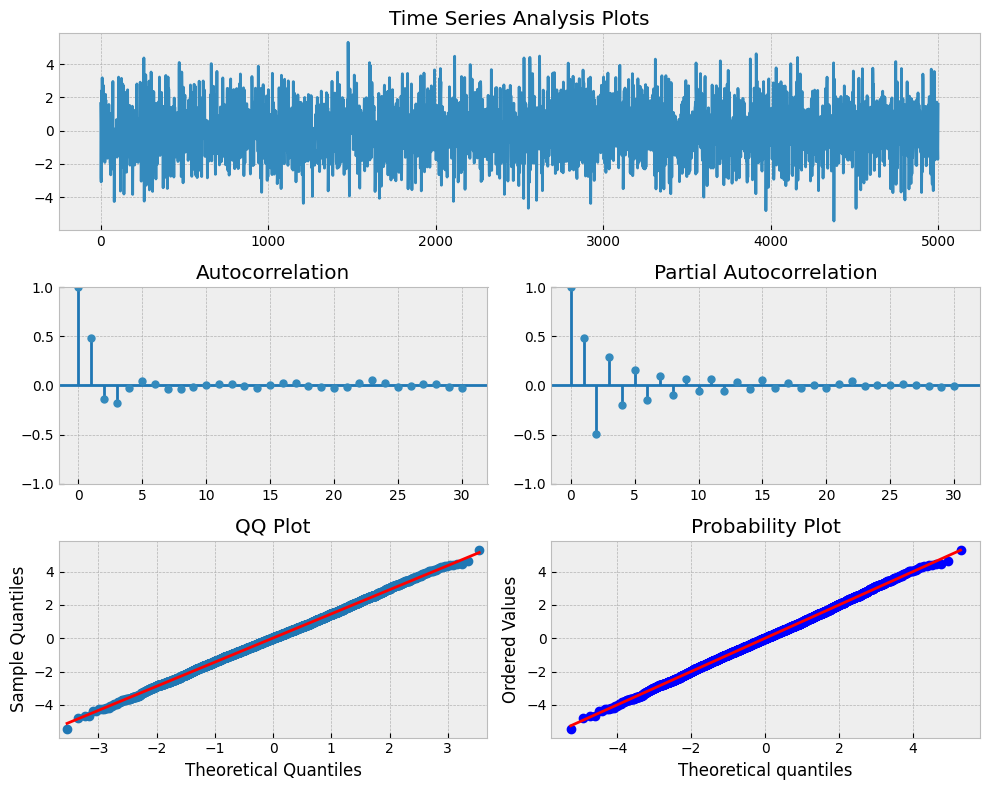

In [113]:
max_lag = 30

n = int(5000) # lots of samples to help estimates
burn = int(n/10) # number of samples to discard before fit

alphas = np.array([0.5, -0.25])
betas = np.array([0.5, -0.3])
ar = np.r_[1, -alphas]
ma = np.r_[1, betas]

arma22 = smt.arma_generate_sample(ar=ar, ma=ma, nsample=n, burnin=burn)
_ = tsplot(arma22, lags=max_lag)

In [114]:
mdl = ARIMA(
    arma22,
    order=(2, 0, 2),
    trend = "n",
    seasonal_order = (0,0,0,0)
).fit()
mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 5000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -7052.723
Date:                Wed, 22 Mar 2023   AIC                          14115.447
Time:                        19:06:39   BIC                          14148.033
Sample:                             0   HQIC                         14126.868
                               - 5000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4052      0.063      6.439      0.000       0.282       0.529
ar.L2         -0.2472      0.015    -16.237      0.000      -0.277      -0.217
ma.L1          0.6229      0.064      9.688      0.000       0.497       0.749
ma.L2         -0.1902      0.059     -3.242      0.001      -0.305      -0.075
sigma2         0.9830      0.020     49.596      0.000       0.944       1.022
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.12
Prob(Q):                              0.94   Prob(JB):                         0.94
Heteroskedasticity (H):               0.97   Skew:                             0.00
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The model has correctly recovered our parameters, and our true parameters are contained within the 95% confidence interval.

# ARIMA(p, d, q)

*Autoregressive Integrated Moving Average Models*

ARIMA is a natural extension to the class of ARMA models. Many of TS are not stationary, however they can be made stationary by differencing. We saw an example of this when we took the first difference of a Guassian random walk and proved that it equals white noise. Said another way, we took the nonstationary random walk and transformed it to stationary white noise by first-differencing.

In [79]:
best_aic = np.inf 
best_order = None
best_mdl = None

pq_rng = range(5) # [0,1,2,3,4]
d_rng = range(2) # [0,1]
for i in pq_rng:
    for d in d_rng:
        for j in pq_rng:
            try:
                # tmp_mdl = ARIMA(lrets.SPY, order=(i,d,j)).fit(method='mle', trend='nc')
                tmp_mdl = ARIMA(
                    apple_data.log_returns.dropna().values,
                    order=(i,d,j),
                    trend = "n",
                    seasonal_order = (0,0,0,0)
                ).fit()
                tmp_aic = tmp_mdl.aic
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (i, d, j)
                    best_mdl = tmp_mdl
            except: continue


print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))

# ARIMA model resid plot
_ = tsplot(best_mdl.resid, lags=30)

# References 
* https://arch.readthedocs.io/en/latest/index.html
* http://www.seanabu.com/2016/03/22/time-series-seasonal-ARIMA-model-in-python/
* https://stats.stackexchange.com/questions/101274/how-to-interpret-a-qq-plot